**ParkerNet Version 1.1 Occlusion/Ablation testing and Appendix B figures**

This notebook can be used to perform  (1) occlusion/ablation testing on Version 1 of ParkerNet on both MAG + SPC and MAG + SPANI datasets  and (2) plot the figures in appendix B.

Note to user: This is a simpler version of a full ablation test, where after zeroing out a feature, you would retrain. Here we only zero out features during inference.


**Files Provided**

**SPC**:

Files used for Prediction:

ParkerNet_allModel_averaged_predictions_E1_20181109.csv

ParkerNet_allModel_averaged_predictions_E2_20190331.csv

ParkerNet_allModel_averaged_predictions_E4_20200124.csv

ParkerNet_allModel_averaged_predictions_E5_20200602.csv

ParkerNet_allModel_averaged_predictions_E6_20200918.csv

ParkerNet_allModel_averaged_predictions_E7_20210112.csv

ParkerNet_allModel_predictions_E8_Oct30_AUCPRC.csv


Files with predictions from Notebook 2:

ParkerNet_allModel_averaged_predictions_E1_20181109.csv

ParkerNet_allModel_averaged_predictions_E2_20190331.csv

ParkerNet_allModel_averaged_predictions_E4_20200124.csv

ParkerNet_allModel_averaged_predictions_E5_20200602.csv

ParkerNet_allModel_averaged_predictions_E6_20200918.csv

ParkerNet_allModel_averaged_predictions_E7_20210112.csv

ParkerNet_allModel_predictions_E8_Oct30_AUCPRC.csv

**SPANI**:

Files used for Prediction:

PSP_E4_ForPrediction_SPANI.txt

PSP_E5_ForPrediction_SPANI.txt

PSP_E6_ForPrediction_SPANI.txt

PSP_E7_ForPrediction_SPANI.txt

PSP_E8_ForPrediction_SPANI.txt

Files with predictions from Notebook 2:

ParkerNet_allModel_averaged_predictions_E4_SPANI.csv

ParkerNet_allModel_averaged_predictions_E5_SPANI.csv

ParkerNet_allModel_predictions_E6_SPANI.csv

ParkerNet_allModel_averaged_predictions_E7_SPANI.csv

ParkerNet_allModel_predictions_E8_SPANI.csv

**Training file**

- `PSP_E1toE7_July23_nonoise.txt`
This file can be accessed at: [![DOI](https://zenodo.org/badge/DOI/10.5281/zenodo.14902750.svg)](https://doi.org/10.5281/zenodo.14902750)


# ====== Load Packages ======


________________________________________________________________________________________________________________________________________________________________

We will start by loading all the packages we will need for this project.

In [12]:
import pandas as pd
import os
import numpy as np
import keras
from keras import backend as K
#from keras.models import Sequential
#from keras.layers import Conv1D, MaxPooling1D,Activation, Dense, Dropout, Flatten, TimeDistributed, Bidirectional, LSTM, GlobalMaxPool1D, GlobalAveragePooling1D
from keras.models import load_model
from tensorflow.keras.layers import  Input
#from keras.optimizers import Adam
import matplotlib.pyplot as plt
#from time import time
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, precision_recall_curve
from sklearn.metrics import roc_auc_score, roc_curve, f1_score, precision_score, recall_score, accuracy_score, auc
from sklearn.metrics import precision_score, recall_score, f1_score, average_precision_score
from keras import initializers
import tensorflow as tf
import random







In [ ]:
# Print versions
print("Versions of installed libraries:")
print(f"pandas: {pd.__version__}")
print(f"numpy: {np.__version__}")
print(f"keras: {keras.__version__}")
print(f"tensorflow: {tf.__version__}")
print(f"matplotlib: {plt.matplotlib.__version__}")
print(f"seaborn: {sns.__version__}")
print(f"scikit-learn: {sns.__version__}")

Versions of installed libraries:
pandas: 2.2.2
numpy: 2.0.2
keras: 3.8.0
tensorflow: 2.18.0
matplotlib: 3.10.0
seaborn: 0.13.2
scikit-learn: 0.13.2


When running this notebook locally, ignore the google drive specific commands and simply read in the provided .txt files needed from your local folder.

In [2]:
from google.colab import drive
drive.mount('/content/MyDrive')

Mounted at /content/MyDrive


In [3]:
cd MyDrive/MyDrive

/content/MyDrive/MyDrive


In [4]:

# Load the dataset used for training
df = pd.read_csv('PSP_E1toE7_July23_nonoise.txt', sep="\t", parse_dates=['Datetime'], index_col='Datetime')


df['Class'] = df['Class'].map({True: 1, False: 0}).astype(int)

# Drop unnecessary columns
df.pop("indices")
df.pop("Encounter")
X_HCI_train = df.pop("X_HCI")
Y_HCI_train = df.pop("Y_HCI")
Z_HCI_train = df.pop("Z_HCI")
df.pop("Dist")

# Preview the dataset
df.head()


,B_r,Bmag,B_t,B_n,V_r,V_t,V_n,Vmag,V_nr,ProtonDensity,Class
Datetime,,,,,,,,,,,
2018-11-04 00:00:00.000,-66.058226,70.255204,-4.140612,-23.557585,267.886,-28.3115,-39.9285,272.321015,48.947177,391.665,0
2018-11-04 00:00:00.873,-65.699724,70.171543,-3.381591,-24.416317,263.905,-69.5283,-43.8579,276.411919,82.205230,536.104,0
2018-11-04 00:00:01.747,-66.442084,70.452417,-8.469396,-21.846322,266.871,-41.5544,-24.7354,271.217143,48.359158,367.138,0
2018-11-04 00:00:02.621,-65.771892,70.127234,-15.798794,-18.500954,260.689,-57.2835,-41.0414,270.045460,70.468403,504.809,0
2018-11-04 00:00:03.495,-64.232595,70.390542,-18.842718,-21.770487,267.265,-26.0570,-45.9163,272.429540,52.794639,394.882,0


In [5]:
# Read in the dataset for predicting and performin occlusion - here we use E4 as an example
df_E4 = pd.read_csv('PSP_E4_ForPrediction.txt', sep="\t", parse_dates=['Datetime'],index_col='Datetime')

# Separate the 'Class_Huang_Ex' column into df_gt
df_gt_E4 = df_E4[['Class_Huang_E4_Range']].copy()

pd.set_option('future.no_silent_downcasting', True)
df_gt_E4['Class_Huang_E4_Range'] = df_gt_E4['Class_Huang_E4_Range'].replace({True: 1, False: 0}).infer_objects(copy=False).astype(int)
# Create df_test by dropping the 'Class_Huang_Ex' column and other columns not needed
df_test_E4 = df_E4.drop(columns=['Class_Huang_E4_Range'])

df_test_E4.pop("X_HCI")
df_test_E4.pop("Y_HCI")
df_test_E4.pop("Z_HCI")

df_test_E4.head()
display(df_test_E4)
df_gt_allpreds_E4 = pd.read_csv('ParkerNet_allModel_averaged_predictions_E4_20200124.csv')
df_test_E4.reset_index(drop=True, inplace=True)
df_gt_allpreds_E4.reset_index(drop=True, inplace=True)
df_ensemble_E4 = pd.concat([df_gt_allpreds_E4, df_test_E4], axis=1, join='inner')
display(df_ensemble_E4)
display(df_test_E4)

,B_r,Bmag,B_t,B_n,V_r,V_t,V_n,Vmag,V_nr,ProtonDensity
Datetime,,,,,,,,,,
2020-01-24 00:00:00.000000000,-54.971393,55.505030,6.204191,-4.523532,290.319,-4.531300,-7.78462,290.458697,9.007385,75.6870
2020-01-24 00:00:00.873799999,-54.983759,55.503786,5.895654,-4.764215,289.983,5.931580,-27.08480,291.305527,27.726703,77.1261
2020-01-24 00:00:01.747599999,-54.749427,55.456405,4.600898,-7.532919,303.232,7.239630,-18.40840,303.876500,19.780835,64.5267
2020-01-24 00:00:02.621399999,-54.775518,55.514759,5.824396,-6.899816,287.891,12.675100,-9.14296,288.314897,15.628560,72.8868
2020-01-24 00:00:03.495199999,-55.319875,55.828496,4.752707,-5.826167,292.176,6.862500,-12.67550,292.531327,14.413959,75.1667
...,...,...,...,...,...,...,...,...,...,...
2020-01-24 23:59:56.974996393,-47.876006,60.464606,-17.230903,32.664241,351.932,-5.744350,58.85750,356.865991,59.137153,102.8180
2020-01-24 23:59:57.848796393,-48.398893,62.039475,-20.570964,32.913206,333.876,8.593740,72.54780,341.775100,73.055018,113.5450
2020-01-24 23:59:58.722596393,-50.032655,60.008524,-6.344302,32.519322,343.835,-15.288900,66.39930,350.521219,68.136756,109.4450


,Class_Huang_E4_Range,Preds_splitM_seed493,Preds_splitM_seed552,Preds_splitM_seed838,Preds_splitM_seed1022,Preds_splitM_seed123,Preds_splitM_seed324,Preds_splitM_seed369,Preds_splitM_seed564,Preds_splitM_seed641,...,B_r,Bmag,B_t,B_n,V_r,V_t,V_n,Vmag,V_nr,ProtonDensity
0,0,0.225500,0.106970,0.392752,0.201537,0.150364,0.125524,0.228964,0.192794,0.175591,...,-54.971393,55.505030,6.204191,-4.523532,290.319,-4.53130,-7.78462,290.458697,9.007385,75.6870
1,0,0.225432,0.107076,0.394596,0.201684,0.151148,0.125573,0.229211,0.193477,0.175677,...,-54.983759,55.503786,5.895654,-4.764215,289.983,5.93158,-27.08480,291.305527,27.726703,77.1261
2,0,0.226401,0.107031,0.395282,0.202159,0.151360,0.125634,0.228885,0.194655,0.175807,...,-54.749427,55.456405,4.600898,-7.532919,303.232,7.23963,-18.40840,303.876500,19.780835,64.5267
3,0,0.226327,0.107098,0.397451,0.202588,0.151330,0.125653,0.228664,0.194406,0.175987,...,-54.775518,55.514759,5.824396,-6.899816,287.891,12.67510,-9.14296,288.314897,15.628560,72.8868
4,0,0.226108,0.107092,0.399911,0.202303,0.151105,0.125635,0.228947,0.194935,0.175625,...,-55.319875,55.828496,4.752707,-5.826167,292.176,6.86250,-12.67550,292.531327,14.413959,75.1667
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
98825,0,0.443982,0.194014,0.347529,0.330143,0.367308,0.177201,0.314858,0.192259,0.157163,...,-51.253870,60.103443,4.883095,31.010000,328.926,19.04000,61.42970,335.154357,64.312749,108.6550
98826,0,0.442554,0.194382,0.348945,0.330629,0.366183,0.177589,0.313551,0.192943,0.157315,...,-50.694612,59.782689,4.016715,31.430753,331.046,29.25060,63.08970,338.271137,69.540692,108.5290
98827,0,0.442976,0.194980,0.349515,0.330920,0.364817,0.176895,0.312067,0.192952,0.158103,...,-50.743110,60.242408,3.893364,32.235480,323.722,20.12880,56.92080,329.303932,60.375045,117.0130
98828,0,0.444663,0.196289,0.350982,0.330797,0.364652,0.177647,0.311237,0.194173,0.158330,...,-52.059228,60.190377,8.101530,29.104699,321.205,18.22770,50.59970,325.676574,53.782699,112.5950


,B_r,Bmag,B_t,B_n,V_r,V_t,V_n,Vmag,V_nr,ProtonDensity
0,-54.971393,55.505030,6.204191,-4.523532,290.319,-4.531300,-7.78462,290.458697,9.007385,75.6870
1,-54.983759,55.503786,5.895654,-4.764215,289.983,5.931580,-27.08480,291.305527,27.726703,77.1261
2,-54.749427,55.456405,4.600898,-7.532919,303.232,7.239630,-18.40840,303.876500,19.780835,64.5267
3,-54.775518,55.514759,5.824396,-6.899816,287.891,12.675100,-9.14296,288.314897,15.628560,72.8868
4,-55.319875,55.828496,4.752707,-5.826167,292.176,6.862500,-12.67550,292.531327,14.413959,75.1667
...,...,...,...,...,...,...,...,...,...,...
98875,-47.876006,60.464606,-17.230903,32.664241,351.932,-5.744350,58.85750,356.865991,59.137153,102.8180
98876,-48.398893,62.039475,-20.570964,32.913206,333.876,8.593740,72.54780,341.775100,73.055018,113.5450
98877,-50.032655,60.008524,-6.344302,32.519322,343.835,-15.288900,66.39930,350.521219,68.136756,109.4450
98878,-47.052271,60.242452,-23.078997,29.708531,343.883,0.650862,79.05050,352.852551,79.053179,110.1350


In [6]:
#test M`, train: E1 to E4, val:E5-E6 EOD Sept 23, test 1:E6 Sept 24 + E7
Xtrain = df.iloc[0:1615023,:-1] #everything but the last column (split1)
ytrain = df.iloc[0:1615023,-1]#only pick the last column
Xval = df.iloc[1615023:1788065,:-1] #everything but the last column (split 1)
yval = df.iloc[1615023:1788065,-1]#only pick the last column
Xtest1 = df.iloc[1788065:,:-1] #everything but the last column
ytest1 = df.iloc[1788065:,-1]#only pick the last column

In [7]:

Xpred_E4 = df_test_E4

train_mean = Xtrain.mean()
train_std = Xtrain.std()

train_df = (Xtrain - train_mean) / train_std

pred_df_E4 = (Xpred_E4- train_mean) / train_std

In [8]:
#use this for test set with no labels, so since the prediction set has no labels yet you will use this sequence function which is simply a modified version of the split_sequences_nolags function above
def split_sequences_nolags_test(dataset, time_steps):
    data_X = []
    for i in range(len(dataset)-time_steps):
        a = dataset.iloc[i:(i+time_steps)]
        data_X.append(a)
        #data_Y.append(labels.iloc[i:i + time_steps])
    return np.array(data_X)

In [9]:
pred_features_new_E4 = split_sequences_nolags_test(pred_df_E4,50) #note that the no class label sequence function is used here.


In [10]:
POS_WEIGHT = 200
POS_WEIGHT = POS_WEIGHT
@keras.saving.register_keras_serializable()
def weighted_binary_crossentropy(target, output):
    """
    Weighted binary crossentropy between an output tensor
    and a target tensor. POS_WEIGHT is used as a multiplier
    for the positive targets.

    Combination of the following functions:
    * keras.losses.binary_crossentropy
    * keras.backend.tensorflow_backend.binary_crossentropy
    * tf.nn.weighted_cross_entropy_with_logits
    """
    # transform back to logits
    _epsilon = tf.convert_to_tensor(tf.keras.backend.epsilon(), output.dtype.base_dtype)
    output = tf.clip_by_value(output, _epsilon, 1 - _epsilon)
    output = tf.math.log(output / (1 - output))
    loss = tf.nn.weighted_cross_entropy_with_logits(labels=target, logits=output, pos_weight=POS_WEIGHT)

    return tf.reduce_mean(loss, axis=-1)

**OCCLUSION STUDY**

Below you can find the function used to calculate ablation for each prediction dataset.

1) Load in a prediction datatset (either SPC or SPANI).

2) Load in a pre-trained ParkerNet model (you may do this for multiple models, but here we choose one for simplicity).

3) Perform feature occlusion and save impact of each features in a csv for plottin

In [13]:


def get_model_name(filepath):
    filename = os.path.basename(filepath)
    filename = os.path.splitext(filename)[0]
    return "_".join(filename.split('_')[2:])

model_paths = [
    'ParkerNet_10162024_splitM_seed3364.keras'
]

df_allprobs = pd.DataFrame()

def predict_and_store(model, model_name, df, pred_features):
    probs_pred = model.predict(pred_features, batch_size=1024, verbose=0)
    final_classification = np.mean(probs_pred, axis=1)
    df[model_name] = pd.Series(np.squeeze(final_classification))
    return df

for model_path in model_paths:
    model = load_model(model_path, custom_objects={
        'weighted_binary_crossentropy': weighted_binary_crossentropy
    })
    model_name = get_model_name(model_path)
    pred_column_name = f'Preds_{model_name}'
    df_allprobs = predict_and_store(model, pred_column_name, df_allprobs, pred_features_new_E4) #MAKE SURE TO CHANGE the "pred_features_new_E4" to match the prediction dataset you are using!!!!

# ─── Metrics and Feature Definitions ───────────────────────────────────────────
feature_names = [
    'B_r', 'B_t', 'B_n', 'Bmag',
    'V_r', 'V_t', 'V_n', 'Vmag',
    'V_nr', 'ProtonDensity'
]

feature_group_patterns = {
    'MAG_all':        r'^B_',
    'Plasma_all':     r'^V_|ProtonDensity',
    'Velocity_only':  r'^V_(r|t|n)$',
    'MAG+Bmag':       r'B_(r|t|n)|Bmag',
    'B_and_Vmag':     r'(Bmag|Vmag)',
}

#calculate a bunch of metrics eventhough AUC-PRC is most useful.
def metrics_func(y_true, y_pred_probs, threshold=0.6):
    y_pred = (y_pred_probs >= threshold).astype(int)
    return {
        'precision':    precision_score(y_true, y_pred, zero_division=0),
        'recall':       recall_score(y_true, y_pred, zero_division=0),
        'f1_score':     f1_score(y_true, y_pred, zero_division=0),
        'auc_prc':      average_precision_score(y_true, y_pred_probs)
    }



# ─── Ablation/Occlusion Study Function ──────────────────────────────────────────────────
def feature_ablation_study(model, X_test, y_test, feature_names,
                           metrics_func, feature_group_patterns=None,
                           batch_size=1024, baseline_pred=None):

    def predict_mean(model, X_input):
        probs = model.predict(X_input, batch_size=batch_size, verbose=0)
        return np.mean(probs, axis=1)

    # 1) Baseline
    if baseline_pred is None:
        baseline_probs = predict_mean(model, X_test)
    else:
        baseline_probs = baseline_pred
    baseline_metrics = metrics_func(y_test, baseline_probs)

    results = []
    X_base = X_test.copy()

    # 2) Single-feature ablations
    for i, fname in enumerate(feature_names):
        X_mod = X_base.copy()
        X_mod[..., i] = 0
        ablated_probs = predict_mean(model, X_mod)
        m = metrics_func(y_test, ablated_probs)
        rel = {
            f'relative_{k}': (baseline_metrics[k] - v) / baseline_metrics[k]
            for k, v in m.items() if baseline_metrics[k] != 0 # k = name of metric, v = metric value (e.g., precision, recall, F1, AUC-PRC) AFTER feature is occluded (zeroed out)
        }
        results.append({'ablated_features': fname, **m, **rel})

    # 3) Group-feature ablations - this is OPTIONAL. We have not fully tested this yet and the group patterns given above are examples only.
    if feature_group_patterns:
        import re
        for grp, pat in feature_group_patterns.items():
            idxs = [i for i, f in enumerate(feature_names) if re.search(pat, f)]
            if not idxs:
                continue
            X_mod = X_base.copy()
            X_mod[..., idxs] = 0
            ablated_probs = predict_mean(model, X_mod)
            m = metrics_func(y_test, ablated_probs)
            rel = {
                f'relative_{k}': (baseline_metrics[k] - v) / baseline_metrics[k]
                for k, v in m.items() if baseline_metrics[k] != 0
            }
            results.append({'ablated_features': grp, **m, **rel})

    return pd.DataFrame(results)


In [14]:
ablation_results = feature_ablation_study(
    model=model,
    X_test=pred_features_new_E4,                     # input features
    y_test=df_ensemble_E4['Class_Huang_E4_Range'].values,  #  ground truth labels, using df_ensemble_EX to have matching lengths. The predictions are 50 ts shorter than the original df_test_E8 due to the last window missing (a fix has been made to the training notebook for future work)
    feature_names=feature_names,
    metrics_func=metrics_func,
    feature_group_patterns=None, #if you want to use the grouped patterns use feature_group_patterns
    batch_size=1024,
    baseline_pred=None
)


In [ ]:
#ablation_results.to_csv("ablation_results_E4.csv", index=False) # Uncomment to save results to a .csv

Notes to user: Here we have saved each file as " ablation_results_EX " for MAG + SPC data and "ablation_results_EX_SPANI" for MAG + SPANI data. Either keep the same naming convention or adapt the code below to your naming structure.

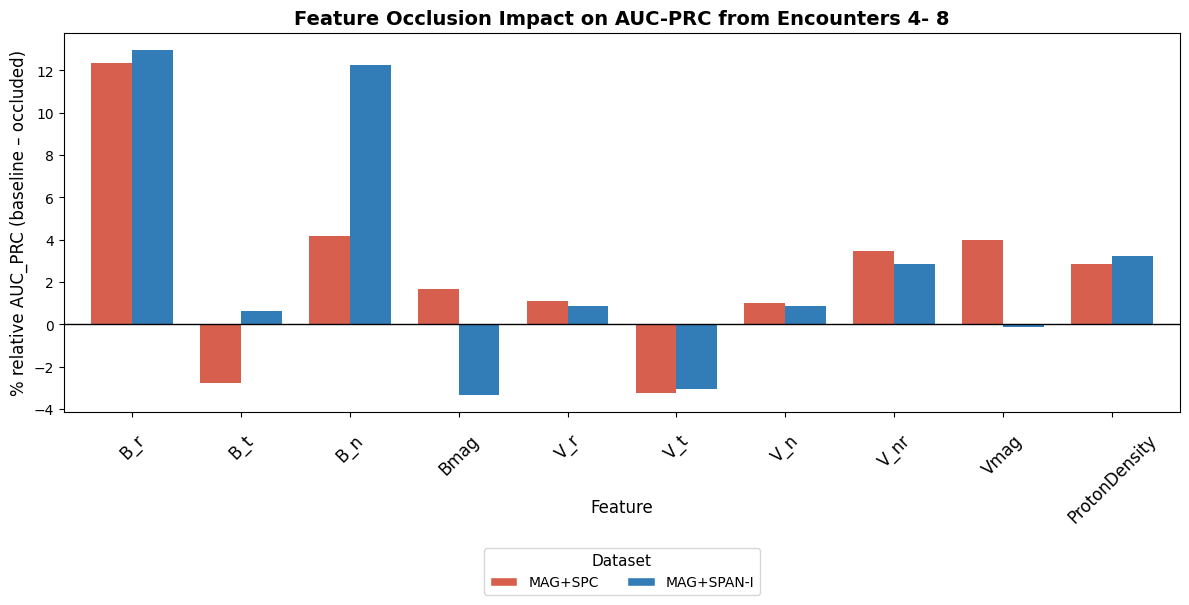

In [15]:
from matplotlib.patches import Patch


# --- Initial Setup ---
encounters = [ 'E4', 'E5', 'E6', 'E7', 'E8']
feature_order = [
    'B_r', 'B_t', 'B_n', 'Bmag',
    'V_r', 'V_t', 'V_n', 'V_nr', 'Vmag', 'ProtonDensity'
]
mean_records = []

# --- Collect impact data ---
for enc in encounters:
    spc_file   = f'ablation_results_{enc}.csv'
    spani_file = f'ablation_results_{enc}_SPANI.csv'
    if not (os.path.exists(spc_file) and os.path.exists(spani_file)):
        continue

    df_spc   = pd.read_csv(spc_file)
    df_spani = pd.read_csv(spani_file)

    # normalize to % impact
    for df in (df_spc, df_spani):
        if 'relative_auc_prc' in df.columns:
            df['% Impact'] = df['relative_auc_prc'] * 100

    # record each feature's impact
    for feat in feature_order:
        for df, label in ((df_spc, 'MAG+SPC'), (df_spani, 'MAG+SPAN-I')):
            val = df.loc[df['ablated_features'] == feat, '% Impact']
            if not val.empty:
                mean_records.append({
                    'Feature': feat,
                    'Dataset': label,
                    'Impact': val.iloc[0]
                })

# --- Build summary DataFrame ---
df_mean = pd.DataFrame(mean_records)
df_summary = (
    df_mean
    .groupby(['Feature', 'Dataset'])['Impact']
    .mean()
    .unstack()[['MAG+SPC', 'MAG+SPAN-I']]
    .loc[feature_order]
)

# --- Choose colors from RdBu ---
cmap   = plt.get_cmap('RdBu')
orange = cmap(0.20)   # burnt‐orange
blue   = cmap(0.85)   # deep blue
colors = [orange, blue]

# --- Plot ---
fig, ax = plt.subplots(figsize=(12, 6))
df_summary.plot(
    kind='bar',
    ax=ax,
    color=colors,
    width=0.75,
    legend=False
)

# zero-line
ax.axhline(0, color='black', linewidth=1)

# titles & labels
ax.set_title(
    'Feature Occlusion Impact on AUC-PRC from Encounters 4- 8',
    fontsize=14, fontweight='bold'
)
ax.set_ylabel('% relative AUC_PRC (baseline – occluded)', fontsize=12)
ax.set_xlabel('Feature', fontsize=12, labelpad=-20)  # move the 'Feature' label up

# lift tick labels so they clear the legend
ax.tick_params(
    axis='x',
    rotation=45,
    labelsize=12,
    pad=10
)

# dynamic legend handles
datasets = df_summary.columns.tolist()
handles = [
    Patch(facecolor=col, edgecolor='white', label=ds)
    for col, ds in zip(colors, datasets)
]
ax.legend(
    handles=handles,
    title='Dataset',
    fontsize=10, title_fontsize=11,
    loc='lower center',
    bbox_to_anchor=(0.5, -0.5),
    ncol=2
)

# adjust margins and show
plt.subplots_adjust(bottom=0.30)
#plt.savefig('APJS_Occlusion_E4toE8.svg', dpi=600, bbox_inches='tight')
#plt.savefig('APJS_Occlusion_E4toE8.pdf', dpi=600, bbox_inches='tight')
plt.tight_layout()
plt.show()


In [16]:
# Check that the plotted values match expectations — matplotlib can sometimes assign colors inconsistently when done dynamically
# --- Build summary DataFrame ---
df_mean = pd.DataFrame(mean_records)
df_summary = (
    df_mean
    .groupby(['Feature', 'Dataset'])['Impact']
    .mean()
    .unstack()[['MAG+SPC', 'MAG+SPAN-I']]
    .loc[feature_order]
)

# --- Print table of values being plotted ---
print("\n=== Feature Occlusion % Impact (Averaged Across E4–E8) ===")
print(df_summary.round(2).to_string())



=== Feature Occlusion % Impact (Averaged Across E4–E8) ===
Dataset        MAG+SPC  MAG+SPAN-I
Feature                           
B_r              12.37       12.98
B_t              -2.76        0.65
B_n               4.17       12.27
Bmag              1.69       -3.33
V_r               1.11        0.87
V_t              -3.25       -3.04
V_n               1.01        0.85
V_nr              3.48        2.85
Vmag              4.00       -0.11
ProtonDensity     2.84        3.21


In [4]:

from sklearn.metrics import average_precision_score

# List of SPC prediction files mapped to encounters
spc_files = {
    'E1': 'ParkerNet_allModel_averaged_predictions_E1_20181109.csv',
    'E2': 'ParkerNet_allModel_averaged_predictions_E2_20190331.csv',
    'E4': 'ParkerNet_allModel_averaged_predictions_E4_20200124.csv',
    'E5': 'ParkerNet_allModel_averaged_predictions_E5_20200602.csv',
    'E6': 'ParkerNet_allModel_averaged_predictions_E6_20200918.csv',
    'E7': 'ParkerNet_allModel_averaged_predictions_E7_20210112.csv',
    'E8': 'ParkerNet_allModel_predictions_E8_Oct30_AUCPRC.csv'
}

# Store results
results = []

for enc, file in spc_files.items():
    if not os.path.exists(file):
        print(f"Missing file: {file}")
        continue

    df = pd.read_csv(file)

    # Find label column
    label_cols = [col for col in df.columns if 'Class_Huang' in col and 'Range' in col]
    if not label_cols:
        print(f"Missing label column in {file}")
        continue
    label_col = label_cols[0]

    # Find prediction column (with 'AUC' or 'Voting')
    pred_cols = [col for col in df.columns if 'auc' in col.lower() or 'voting' in col.lower()]
    if not pred_cols:
        print(f"Missing prediction column in {file}")
        continue
    pred_col = pred_cols[0]

    y_true = df[label_col].astype(int)
    y_scores = df[pred_col].astype(float)

    # Compute AUC-PRC
    auc_prc = average_precision_score(y_true, y_scores)
    results.append({'Encounter': enc, 'AUC-PRC - MAG + SPC': round(auc_prc, 4)})

# Convert to DataFrame and print
results_df_SPC = pd.DataFrame(results)
print(results_df_SPC)


  Encounter  AUC-PRC - MAG + SPC
0        E1               0.8626
1        E2               0.7289
2        E4               0.6852
3        E5               0.7679
4        E6               0.9021
5        E7               0.7072
6        E8               0.5452


In [17]:

from sklearn.metrics import average_precision_score

# List of SPANI prediction files mapped to encounters
spani_files = {
    'E4': 'ParkerNet_allModel_averaged_predictions_E4_SPANI.csv',
    'E5': 'ParkerNet_allModel_averaged_predictions_E5_SPANI.csv',
    'E6': 'ParkerNet_allModel_predictions_E6_SPANI.csv',
    'E7': 'ParkerNet_allModel_averaged_predictions_E7_SPANI.csv',
    'E8': 'ParkerNet_allModel_predictions_E8_SPANI.csv'
}

# Store results
results = []

for enc, file in spani_files.items():
    if not os.path.exists(file):
        print(f"Missing file: {file}")
        continue

    df = pd.read_csv(file)

    # Try to find the label column (exact match)
    label_cols = [col for col in df.columns if 'Class_Huang' in col and 'Range' in col]
    if not label_cols:
        print(f"Missing label column in {file}")
        continue
    label_col = label_cols[0]

    # Try to find the prediction column (contains 'AUC' or 'Voting')
    pred_cols = [col for col in df.columns if 'auc' in col.lower() or 'voting' in col.lower()]
    if not pred_cols:
        print(f"Missing prediction column in {file}")
        continue
    pred_col = pred_cols[0]

    y_true = df[label_col].astype(int)
    y_scores = df[pred_col].astype(float)

    # Compute AUC-PRC
    auc_prc = average_precision_score(y_true, y_scores)
    results.append({'Encounter': enc, 'AUC-PRC - MAG + SPANI': round(auc_prc, 4)})

# Convert to DataFrame and print
results_df_SPANI = pd.DataFrame(results)
print(results_df_SPANI)


  Encounter  AUC-PRC - MAG + SPANI
0        E4                 0.6561
1        E5                 0.8065
2        E6                 0.8462
3        E7                 0.7169
4        E8                 0.3832


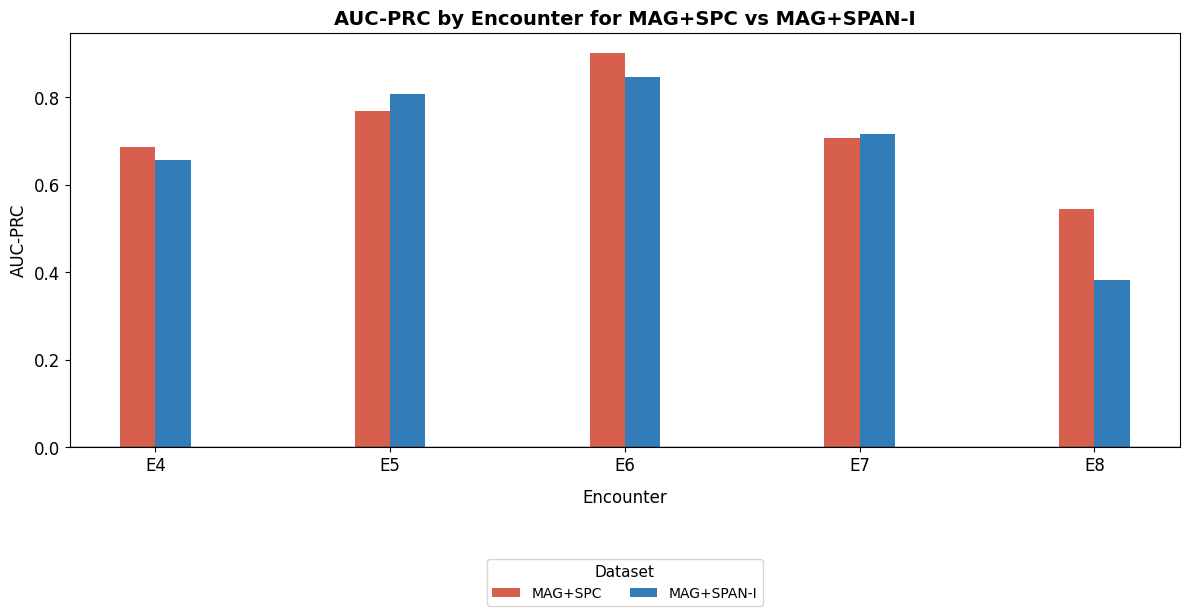

In [ ]:


# --- make sure results_df_SPC and results_df_SPANI are already defined from above cells ---

# extract data


desired_encounters = ['E4', 'E5', 'E6', 'E7', 'E8'] # only using E4 - E8 since SPANI does not capture the core of the solar wind in it's FOV well during these encounters
filtered_spc    = results_df_SPC[results_df_SPC['Encounter'].isin(desired_encounters)]
filtered_spani  = results_df_SPANI[results_df_SPANI['Encounter'].isin(desired_encounters)]

# Extract lists
auc_spc    = filtered_spc['AUC-PRC - MAG + SPC'].tolist()
auc_spani  = filtered_spani['AUC-PRC - MAG + SPANI'].tolist()


# choose colors from RdBu
cmap    = plt.get_cmap('RdBu')
orange  = cmap(0.20)   # burnt‐orange
blue    = cmap(0.85)   # deep blue

# bar positions
x     = np.arange(len(encounters))
width = 0.15

# plot
fig, ax = plt.subplots(figsize=(12, 6))
bars1 = ax.bar(x - width/2, auc_spc,   width, label='MAG+SPC',   color=orange)
bars2 = ax.bar(x + width/2, auc_spani, width, label='MAG+SPAN-I', color=blue)

# zero line for visual anchor
ax.axhline(0, color='black', linewidth=1)

# titles & labels (matching the occlusion figure style)
ax.set_title(
    'AUC-PRC by Encounter for MAG+SPC vs MAG+SPAN-I',
    fontsize=14, fontweight='bold'
)
ax.set_ylabel('AUC-PRC', fontsize=12)
ax.set_xlabel('Encounter', fontsize=12, labelpad=10)

# tick labels
ax.set_xticks(x)
ax.set_xticklabels(encounters, rotation=0, fontsize=12)
ax.tick_params(axis='y', labelsize=12)

# move the legend to bottom center, matching previous style
ax.legend(
    title='Dataset',
    fontsize=10, title_fontsize=11,
    loc='lower center',
    bbox_to_anchor=(0.5, -0.4),
    ncol=2
)

# adjust layout
plt.subplots_adjust(bottom=0.3)
plt.savefig('APJS_MAGSPCvsMAGSPANI_AUCPRC_E4toE8.svg', dpi=600, bbox_inches='tight')
plt.savefig('APJS_MAGSPCvsMAGSPANI_AUCPRC_E4toE8.pdf', dpi=600, bbox_inches='tight')
plt.tight_layout()
plt.show()
